# Assignment Lesson 15- Try Different Clustering Methods

## Introduction
In this assignment I explore DBSCAN (Density-Based Spatial Clustering
of Applications with Noise) as an alternative to K-Means clustering
on the Nigerian music dataset from Spotify. Unlike K-Means, DBSCAN
does not require specifying the number of clusters in advance and can
handle noise and outliners effectively.

**Dataset source:** Microsoft ML for Beginners curriculum -
Nigerian songs scraped from Spotify

In [2]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("../data/nigerian-songs.csv")
df.head()

,name,album,artist,artist_top_genre,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
0,Sparky,Mandy & The Jungle,Cruel Santino,alternative r&b,2019,144000,48,0.666,0.8510,0.420,0.534000,0.1100,-6.699,0.0829,133.015,5
1,shuga rush,EVERYTHING YOU HEARD IS TRUE,Odunsi (The Engine),afropop,2020,89488,30,0.710,0.0822,0.683,0.000169,0.1010,-5.640,0.3600,129.993,3
2,LITT!,LITT!,AYLØ,indie r&b,2018,207758,40,0.836,0.2720,0.564,0.000537,0.1100,-7.127,0.0424,130.005,4
3,Confident / Feeling Cool,Enjoy Your Life,Lady Donli,nigerian pop,2019,175135,14,0.894,0.7980,0.611,0.000187,0.0964,-4.961,0.1130,111.087,4
4,wanted you,rare.,Odunsi (The Engine),afropop,2018,152049,25,0.702,0.1160,0.833,0.910000,0.3480,-6.044,0.0447,105.115,4


## Data Preparation
The Nigerian music dataset contains songs across multiple genres.
We filter it to 3 genres and remove songs with 0 popularity,
then select relevant features for clustering.

In [3]:
df = df[(df['artist_top_genre'] == 'afro dancehall') | (df['artist_top_genre'] == 'afropop') | (df['artist_top_genre'] == 'nigerian pop')]
df = df[(df['popularity'] > 0)]
df.head()

,name,album,artist,artist_top_genre,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
1,shuga rush,EVERYTHING YOU HEARD IS TRUE,Odunsi (The Engine),afropop,2020,89488,30,0.710,0.0822,0.683,0.000169,0.1010,-5.640,0.3600,129.993,3
3,Confident / Feeling Cool,Enjoy Your Life,Lady Donli,nigerian pop,2019,175135,14,0.894,0.7980,0.611,0.000187,0.0964,-4.961,0.1130,111.087,4
4,wanted you,rare.,Odunsi (The Engine),afropop,2018,152049,25,0.702,0.1160,0.833,0.910000,0.3480,-6.044,0.0447,105.115,4
5,Kasala,Pioneers,DRB Lasgidi,nigerian pop,2020,184800,26,0.803,0.1270,0.525,0.000007,0.1290,-10.034,0.1970,100.103,4
6,Pull Up,Everything Pretty,prettyboydo,nigerian pop,2018,202648,29,0.818,0.4520,0.587,0.004490,0.5900,-9.840,0.1990,95.842,4


## Feature Selection and Encoding
We select 6 features for clustering: artist_top_genre, popularity,
danceability, acousticness, loudness, and energy. The
artist_top_genre
column is encoded as numeric since DBSCAN, like K-Means, requires
numeric input.

In [4]:
le = LabelEncoder()

X = df.loc[:, ('artist_top_genre', 'popularity', 'danceability', 'acousticness', 'loudness', 'energy')]

y = df['artist_top_genre']

X['artist_top_genre'] = le.fit_transform(X['artist_top_genre'])
y = le.transform(y)

## DBSCAN Clustering
DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
groups data points that are closely packed together and marks points
in low-density regions as noise. Unlike K-Means, it does not require
specifying the number of clusters in advance.

Two key parameters:
- eps: the maximum distance between two points to be considered neighbours
- min_samples: minimum number of points to form a dense region (cluster)

In [12]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2, min_samples=5)
dbscan.fit(X)

labels = dbscan.labels_
labels

array([ 0,  1,  1, -1, -1, -1, -1,  0,  1, -1,  0,  0, -1,  0, -1, -1,  1,
       -1,  2,  1,  2, -1, -1,  1,  2,  0,  7,  2,  2,  3,  4,  4, -1,  0,
        1, -1,  1,  4,  4,  2,  3,  2,  0,  2,  1,  2,  7,  1,  4,  2,  1,
       -1,  2,  0,  0, -1,  1,  1,  1,  2,  4,  0,  1,  5,  3, -1,  1,  2,
        4,  2,  0,  4, -1,  6,  4,  1,  0,  4,  0,  0,  2,  1,  4,  1,  1,
        0,  0,  3,  0,  1, -1,  0,  0,  0,  1,  6,  1,  6, -1,  1,  1,  1,
        6,  1,  1,  0,  0,  4,  1,  2, -1,  4,  1, -1, -1,  0,  0,  0,  0,
        0,  1,  0,  2, -1,  1,  1,  4,  2,  1,  0,  1,  0,  1,  0,  0,  1,
        2,  0,  1,  4,  1,  0,  1,  8,  5, -1,  0,  6,  1,  4, -1, -1,  1,
        0, -1, -1,  4, -1,  1,  0,  1,  1,  1,  1, -1, -1,  7,  8, -1,  2,
        2, -1, -1, -1, -1,  2, -1,  4,  2,  2,  4,  2,  8,  2,  7, -1,  4,
        1,  0,  2,  0,  2,  2,  0,  0,  5,  4,  2, -1, -1,  2,  2,  4, -1,
        0,  2,  4, -1,  0,  7, -1,  0,  0,  3,  1,  4,  5,  5,  4,  2,  0,
        1,  0,  0, -1,  4

## plotting a visual differentiation between popularity and danceability where -1 is noise

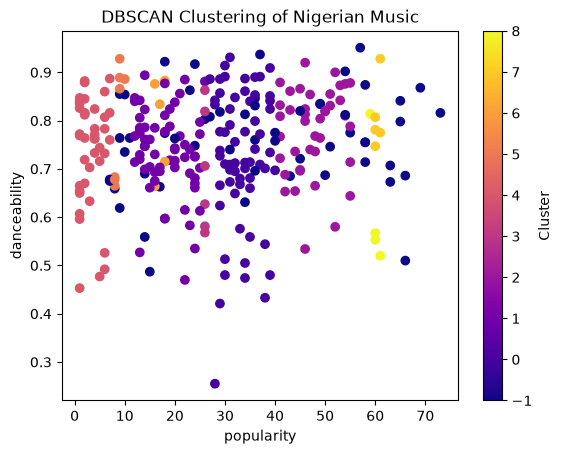

In [13]:
plt.scatter(df['popularity'], df['danceability'], c=labels, cmap='plasma')
plt.xlabel('popularity')
plt.ylabel('danceability')
plt.title('DBSCAN Clustering of Nigerian Music')
plt.colorbar(label='Cluster')
plt.show()

### Observation

The dataset points are too scattered and densely mixed up, and there is too much noise making it too difficult to come to any conclusion

## Here are are looking at the total of clusters and noise in the dataset points above

In [14]:
import numpy as np

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f'Number of clusters found: {n_clusters}')
print(f'Number of noise points: {n_noise}')

Number of clusters found: 9
Number of noise points: 56


### Observation

number of clusters found are 9 while the noise points found are 56, which is too imbalanced to get an concreate conclusion as such this dataset is not the best suit for DBSCAN Clustering

# Final Conclusion

## Learning from the Assignment
The assignment was helpful and a good learning expercience because by doing this I was able to see and do an onhand test that clustering too can be done in many ways on different datasets. 

## Comparision of DBSCAN vs K-Means on the Nigerian Music Dataset
Neither of the methods was good for this specific dataset and some other better suited method could have had been used because the results and accuracy were not solid and trust worthy.

**But**- when we compare only the methods results from each other, I felt that K-Means performed better in comparison to DBSCAN here.

**Why**- Because K-Means silhouette score was around 0.53 while here in DBSCAN, all the focus of the model was on noise because of the amount of noise in the dataset in comparison to clusters.

### FINAL VERDICT, A BETTER METHOD CAN BE USED FOR THIS PERTICULAR DATASET AS NEIHER DBSCAN NOR K-MEANS WAS A GOOD FIT FOR IT.